In [1]:
!pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 55.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
import os, gc, time, random, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0 | Keras: 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:


QUICK_TEST = False
PRETRAINED = True

SEED = 42
N_RUNS = 3

FACE_SIZE = 128
REGION_SIZE = 96
EMB_DIM = 128

DROPOUT = 0.35
AUX_WEIGHT = 0.30

TEST_SIZE = 0.20
VAL_SIZE = 0.20
BATCH_SIZE = 16

WARMUP_EPOCHS = 5
FINETUNE_EPOCHS = 30
FINE_TUNE_LAST_N = 30

WARMUP_LR = 1e-3
FINE_TUNE_LR = 1e-5

# -------------------------------------------------------------------------
# RANDOM REGION DROPOUT — TRAINING ONLY
# -------------------------------------------------------------------------
# 0 = full
# 1 = eyes dropped
# 2 = nose dropped
# 3 = mouth dropped
# 4 = random one of the three regions dropped
RD_PROBS = [0.40, 0.15, 0.15, 0.15, 0.15]

# Mid-gray fill for an explicitly occluded region.
OCC_FILL = 127.5

RESUME = True
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

REGIONS = ["eyes", "nose", "mouth"]
N_REG = len(REGIONS)

COND_NAMES = [
    "Clean",
    "Eyes occluded",
    "Nose occluded",
    "Mouth occluded"
]

# -------------------------------------------------------------------------
# EXPERIMENT MATRIX
# -------------------------------------------------------------------------

CONFIGS = {
    "Prob. fusion (old)": dict(gate="prob_avg", rd=True),
    "Fixed": dict(gate="fixed", rd=True),
    "Learned": dict(gate="learned", rd=True),
    "Confidence-only": dict(gate="confidence", rd=True),
    "Entropy-only": dict(gate="entropy", rd=True),
    "Entropy+Disagree": dict(gate="entropy_disagree", rd=True),
    "Full uncertainty": dict(gate="full", rd=True),

    # Explicit ablation: what happens without random region dropout?
    "Fixed (no RD)": dict(gate="fixed", rd=False),
    "Full uncertainty (no RD)": dict(gate="full", rd=False),
}

GATE_FEATURES = {
    "confidence": ["margin"],
    "entropy": ["entropy"],
    "entropy_disagree": ["entropy", "disagreement"],

    # All four signals requested by ma'am.
    "full": [
        "entropy",
        "margin",
        "variance",
        "disagreement"
    ],
}

MAIN_CONFIGS = [
    "Prob. fusion (old)",
    "Fixed",
    "Learned",
    "Confidence-only",
    "Entropy-only",
    "Entropy+Disagree",
    "Full uncertainty"
]

FULL = "Full uncertainty"

if QUICK_TEST:
    N_RUNS = 1
    WARMUP_EPOCHS = 1
    FINETUNE_EPOCHS = 2
    CONFIGS = {
        k: CONFIGS[k]
        for k in ["Fixed", "Learned", "Full uncertainty"]
    }
    MAIN_CONFIGS = list(CONFIGS.keys())
    RESUME = False

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configurations:")
for i, name in enumerate(CONFIGS, 1):
    print(f"  {i}. {name}")

print(f"\nN_RUNS = {N_RUNS}")

Configurations:
  1. Prob. fusion (old)
  2. Fixed
  3. Learned
  4. Confidence-only
  5. Entropy-only
  6. Entropy+Disagree
  7. Full uncertainty
  8. Fixed (no RD)
  9. Full uncertainty (no RD)

N_RUNS = 3


In [4]:
DATASET_PATH = "/kaggle/input/datasets/navneet0094/jafee-un/jaffe"
BATCH_SIZE = 16
SUBJECT_INDEPENDENT = True       # True = test/val subjects never appear in training (stricter, recommended for the final claim)

EMOTION_MAP = {'AN': 0, 'DI': 1, 'FE': 2, 'HA': 3, 'SA': 4, 'SU': 5, 'NE': 6}
CLASS_NAMES = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sadness', 'Surprise', 'Neutral']

# MediaPipe FaceMesh landmark ids
EYE_OUTER_A, EYE_OUTER_B = 33, 263          # outer corners of the two eyes (used for rotation alignment)
LM_GROUPS = {
    'eyes':  [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246,          # one eye
              362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398,       # other eye
              70, 63, 105, 66, 107, 55, 65, 52, 53, 46, 300, 293, 334, 296, 336, 285, 295, 282, 283, 276],  # eyebrows
    'nose':  [197, 195, 5, 4, 1, 19, 94, 2, 98, 97, 326, 327, 129, 358, 49, 279, 48, 278, 64, 294, 219, 439],
    'mouth': [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 409, 270, 269, 267, 0, 37, 39, 40, 185,
              78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308, 415, 310, 311, 312, 13, 82, 81, 80, 191],
}


In [5]:
from PIL import Image

def load_jaffe(path):
    assert os.path.exists(path), f'Dataset path not found: {path}'
    imgs, labs, subs, names = [], [], [], []
    files = [f for f in os.listdir(path) if f.lower().endswith(('.tiff', '.tif', '.jpg', '.jpeg', '.png'))]
    for fn in sorted(files):
        parts = fn.split('.')
        if len(parts) < 3 or parts[1][:2] not in EMOTION_MAP:
            continue
        imgs.append(np.array(Image.open(os.path.join(path, fn)).convert('RGB'), dtype=np.uint8))
        labs.append(EMOTION_MAP[parts[1][:2]]); subs.append(parts[0]); names.append(fn)
    return imgs, np.array(labs), np.array(subs), np.array(names)

raw_images, labels, subjects, filenames = load_jaffe(DATASET_PATH)
groups = subjects
print(f'Loaded {len(raw_images)} images | subjects: {len(np.unique(subjects))}')


Loaded 213 images | subjects: 10


In [6]:
# ---- landmark helpers (no MediaPipe needed for these) ----
def align_and_crop(rgb, lm, out_size=FACE_SIZE, margin=0.25):
    # rotate so the eye line is horizontal, crop around the landmarks, resize; returns face + landmarks in crop coordinates
    h, w = rgb.shape[:2]
    a, b = lm[EYE_OUTER_A], lm[EYE_OUTER_B]
    angle = np.degrees(np.arctan2(b[1] - a[1], b[0] - a[0]))
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(rgb, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    lm_r = np.hstack([lm, np.ones((len(lm), 1), np.float32)]) @ M.T
    x0, y0 = lm_r.min(0); x1, y1 = lm_r.max(0)
    bw, bh = x1 - x0, y1 - y0
    x0, y0 = int(max(0, x0 - bw * margin)), int(max(0, y0 - bh * margin))
    x1, y1 = int(min(w, x1 + bw * margin)), int(min(h, y1 + bh * margin))
    if x1 - x0 < 10 or y1 - y0 < 10:
        return None, None
    face = cv2.resize(rotated[y0:y1, x0:x1], (out_size, out_size), interpolation=cv2.INTER_AREA)
    lm_c = (lm_r - np.array([x0, y0])) * np.array([out_size / (x1 - x0), out_size / (y1 - y0)])
    return face, lm_c.astype(np.float32)


def boxes_from_landmarks(lm, size=FACE_SIZE, pad=0.15, min_size=24):
    out = []
    for r in REGIONS:
        pts = lm[LM_GROUPS[r]]
        x0, y0 = pts.min(0); x1, y1 = pts.max(0)
        pw, ph = (x1 - x0) * pad, (y1 - y0) * pad
        x0, y0, x1, y1 = x0 - pw, y0 - ph, x1 + pw, y1 + ph
        if x1 - x0 < min_size:
            c = (x0 + x1) / 2; x0, x1 = c - min_size / 2, c + min_size / 2
        if y1 - y0 < min_size:
            c = (y0 + y1) / 2; y0, y1 = c - min_size / 2, c + min_size / 2
        out.append([max(0, int(x0)), max(0, int(y0)), min(size, int(x1)), min(size, int(y1))])
    return np.array(out)


def fixed_boxes(size=FACE_SIZE):
    return np.array([[int(FIXED_BOX_FRAC[r][0] * size), int(FIXED_BOX_FRAC[r][1] * size),
                      int(FIXED_BOX_FRAC[r][2] * size), int(FIXED_BOX_FRAC[r][3] * size)] for r in REGIONS])


In [7]:
# MediaPipe Face Landmarker
import urllib.request
import mediapipe as mp
from mediapipe.tasks.python import vision, BaseOptions

MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve('https://storage.googleapis.com/mediapipe-models/face_landmarker/'
                               'face_landmarker/float16/1/face_landmarker.task', MODEL_PATH)
landmarker = vision.FaceLandmarker.create_from_options(
    vision.FaceLandmarkerOptions(base_options=BaseOptions(model_asset_path=MODEL_PATH), num_faces=1))

def detect_landmarks(img):
    res = landmarker.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(img)))
    if not res.face_landmarks:
        return None
    h, w = img.shape[:2]
    return np.array([[p.x * w, p.y * h] for p in res.face_landmarks[0]], dtype=np.float32)

faces_l, boxes_l, detected = [], [], []
for img in raw_images:
    face = lm_c = None
    try:
        lm = detect_landmarks(img)
        if lm is not None:
            face, lm_c = align_and_crop(img, lm)
    except Exception as e:
        pass
    if face is None:                                             # fallback: plain resize + fixed boxes
        faces_l.append(cv2.resize(img, (FACE_SIZE, FACE_SIZE), interpolation=cv2.INTER_AREA))
        boxes_l.append(fixed_boxes()); detected.append(False)
    else:
        faces_l.append(face); boxes_l.append(boxes_from_landmarks(lm_c)); detected.append(True)

faces = np.array(faces_l, dtype=np.uint8)
boxes = np.array(boxes_l)
print(f'faces: {faces.shape} | boxes: {boxes.shape} | landmarks detected: {sum(detected)}/{len(detected)}')
del raw_images; gc.collect()


W0000 00:00:1790923317.409651     140 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1790923317.424062     145 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790923317.444474     146 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


faces: (213, 128, 128, 3) | boxes: (213, 3, 4) | landmarks detected: 213/213


0

Total images: 213 | classes: 7
Anger       30
Disgust     29
Fear        32
Happy       31
Sadness     31
Surprise    30
Neutral     30


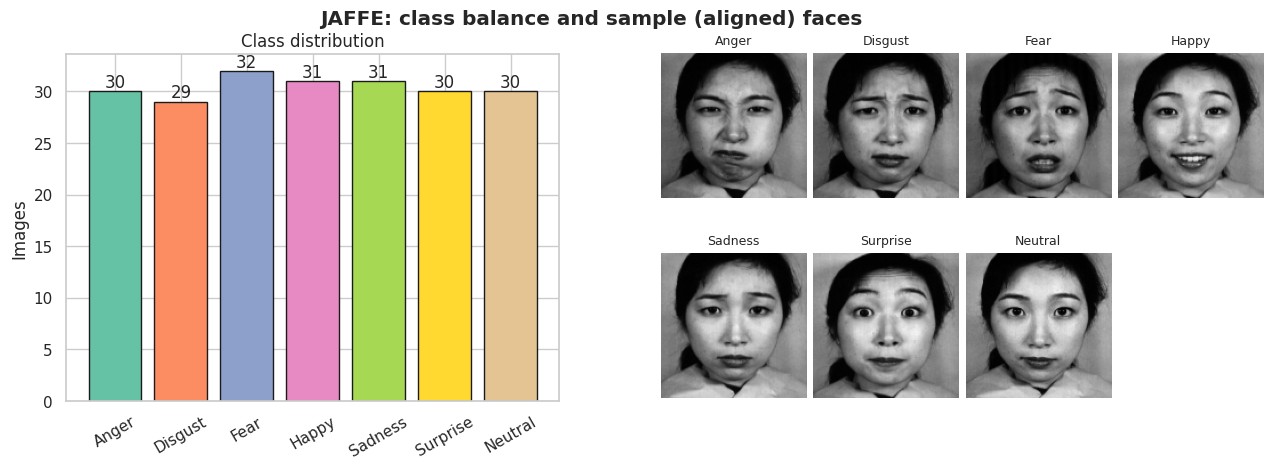

In [8]:
# ---- class distribution + sample faces ----
NUM_CLASSES = len(CLASS_NAMES)
counts = np.bincount(labels, minlength=NUM_CLASSES)
print(f'Total images: {len(labels)} | classes: {NUM_CLASSES}')
print(pd.Series(counts, index=CLASS_NAMES).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
bars = ax[0].bar(CLASS_NAMES, counts, color=sns.color_palette('Set2', NUM_CLASSES), edgecolor='k')
for b in bars:
    ax[0].text(b.get_x() + b.get_width() / 2, b.get_height(), int(b.get_height()), ha='center', va='bottom')
ax[0].set_title('Class distribution'); ax[0].set_ylabel('Images'); ax[0].tick_params(axis='x', rotation=30)
ax[1].axis('off')
inset = fig.add_gridspec(2, 4, left=0.55, right=0.98, top=0.9, bottom=0.1, wspace=0.05, hspace=0.25)
for c in range(min(NUM_CLASSES, 8)):
    a = fig.add_subplot(inset[c // 4, c % 4])
    a.imshow(faces[np.where(labels == c)[0][0]]); a.set_title(CLASS_NAMES[c], fontsize=9); a.axis('off')
plt.suptitle('JAFFE: class balance and sample (aligned) faces', fontweight='bold')
plt.savefig(OUT_DIR / '01_dataset_overview.png', dpi=150, bbox_inches='tight'); plt.show()


crops: (213, 3, 96, 96, 3) uint8 (18 MB)


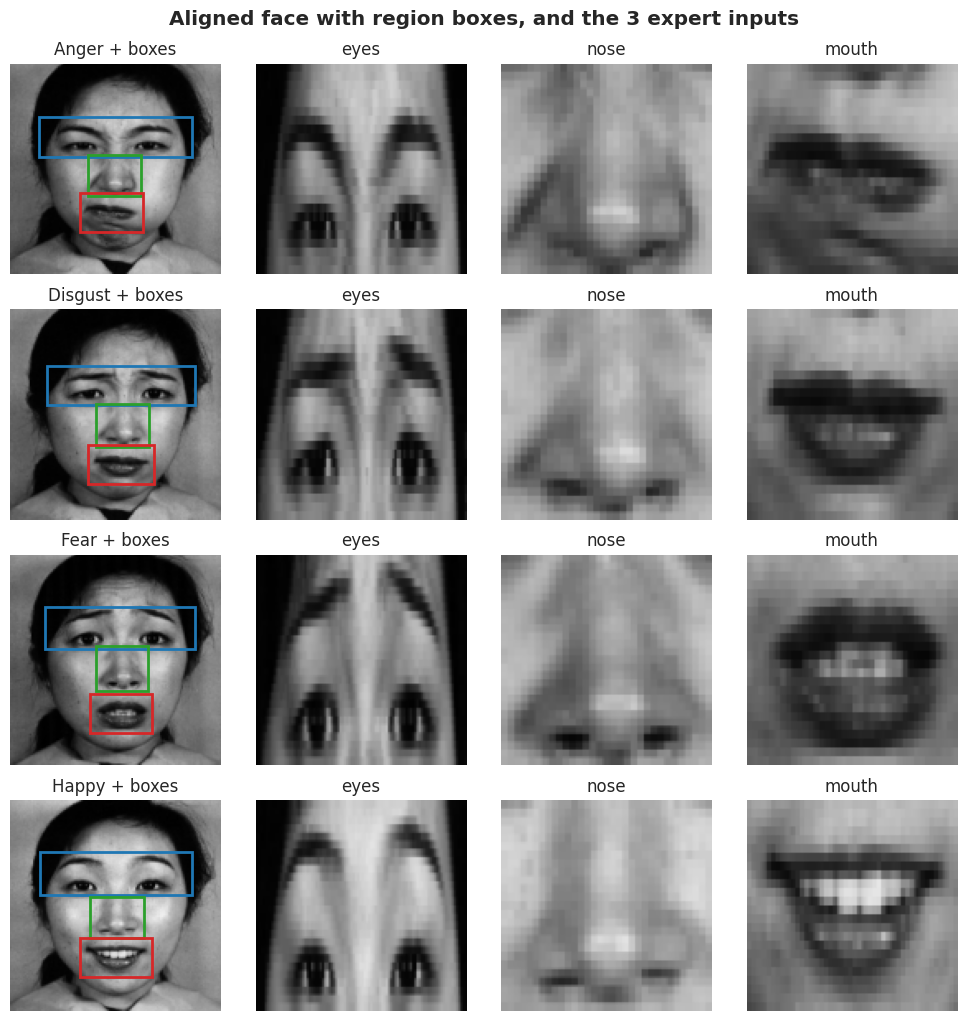

In [9]:
# ---- build crops: (N, 3 regions, REGION_SIZE, REGION_SIZE, 3) uint8 ----
def crop_region(face, box, size=REGION_SIZE):
    x0, y0, x1, y1 = [int(v) for v in box]
    patch = face[y0:y1, x0:x1]
    if patch.size == 0:
        patch = face
    return cv2.resize(patch, (size, size), interpolation=cv2.INTER_AREA)

crops = np.zeros((len(faces), N_REG, REGION_SIZE, REGION_SIZE, 3), dtype=np.uint8)
for i in range(len(faces)):
    for k in range(N_REG):
        crops[i, k] = crop_region(faces[i], boxes[i, k])
print('crops:', crops.shape, crops.dtype, f'({crops.nbytes/1e6:.0f} MB)')

# ---- overlay check ----
REG_COLORS = {'eyes': 'tab:blue', 'nose': 'tab:green', 'mouth': 'tab:red'}
show_idx = [np.where(labels == c)[0][0] for c in range(min(NUM_CLASSES, 4))]
fig, axes = plt.subplots(len(show_idx), 4, figsize=(10, 2.6 * len(show_idx)))
for r, i in enumerate(show_idx):
    axes[r, 0].imshow(faces[i])
    for k, name in enumerate(REGIONS):
        x0, y0, x1, y1 = boxes[i, k]
        axes[r, 0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=REG_COLORS[name], lw=2))
        axes[r, k + 1].imshow(crops[i, k]); axes[r, k + 1].set_title(name)
    axes[r, 0].set_title(f'{CLASS_NAMES[labels[i]]} + boxes')
    for a in axes[r]: a.axis('off')
plt.suptitle('Aligned face with region boxes, and the 3 expert inputs', fontweight='bold')
plt.tight_layout(); plt.savefig(OUT_DIR / '02_regions.png', dpi=150, bbox_inches='tight'); plt.show()


Split (seed 42): train=128 | val(clean)=42 | test=43


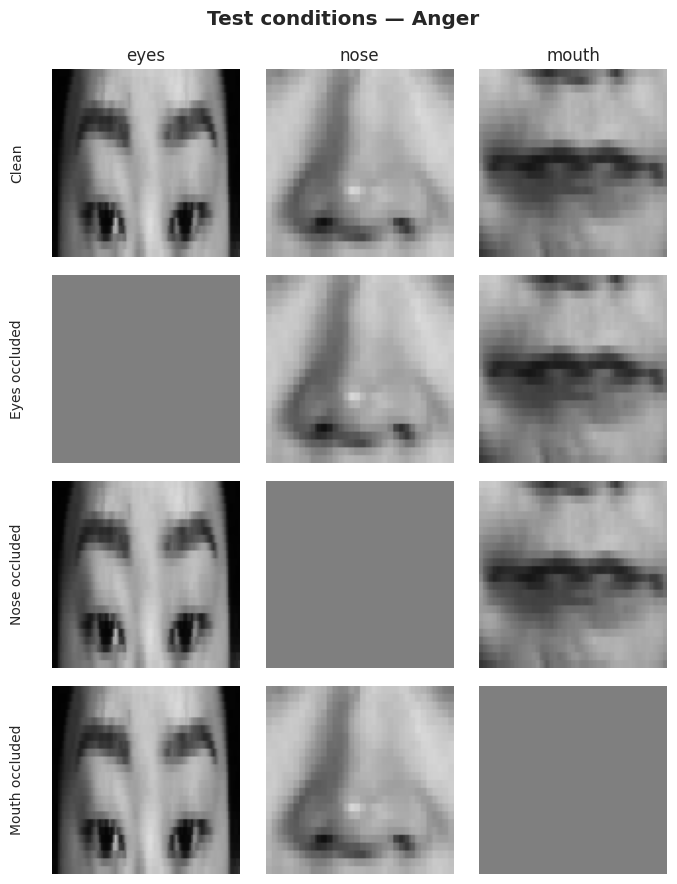

In [10]:
y_cat = keras.utils.to_categorical(labels, NUM_CLASSES).astype('float32')

def make_split(seed):
    idx = np.arange(len(labels))
    if SUBJECT_INDEPENDENT and groups is not None:
        g1 = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
        trval, te = next(g1.split(idx, labels, groups))
        trval, te = idx[trval], idx[te]
        g2 = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=seed)
        a, b = next(g2.split(trval, labels[trval], groups[trval]))
        tr, va = trval[a], trval[b]
    else:
        trval, te = train_test_split(idx, test_size=TEST_SIZE, stratify=labels, random_state=seed)
        tr, va = train_test_split(trval, test_size=VAL_SIZE, stratify=labels[trval], random_state=seed)
    return tr, va, te

def make_inputs(idx):
    return {f'{r}_in': crops[idx, k].astype(np.float32) for k, r in enumerate(REGIONS)}

def make_targets(idx):
    yc = y_cat[idx]
    return {'final_out': yc, **{f'{r}_out': yc for r in REGIONS}}

def occlude(inputs, region):
    out = {k: v.copy() for k, v in inputs.items()}
    out[f'{region}_in'][:] = OCC_FILL
    return out

def build_test_sets(te_idx):
    clean = make_inputs(te_idx)
    return {'Clean': clean,
            'Eyes occluded':  occlude(clean, 'eyes'),
            'Nose occluded':  occlude(clean, 'nose'),
            'Mouth occluded': occlude(clean, 'mouth')}

tr, va, te = make_split(SEED)
print(f'Split (seed {SEED}): train={len(tr)} | val(clean)={len(va)} | test={len(te)}')

# ---- visualise the 4 test conditions for one test image ----
i0 = te[0]
tsets = build_test_sets(np.array([i0]))
fig, axes = plt.subplots(4, 3, figsize=(7, 9))
for r, cond in enumerate(COND_NAMES):
    for k, name in enumerate(REGIONS):
        axes[r, k].imshow(tsets[cond][f'{name}_in'][0].astype('uint8')); axes[r, k].axis('off')
        if r == 0: axes[r, k].set_title(name)
    axes[r, 0].text(-0.15, 0.5, cond, transform=axes[r, 0].transAxes, rotation=90, va='center', ha='right', fontsize=10)
plt.suptitle(f'Test conditions — {CLASS_NAMES[labels[i0]]}', fontweight='bold')
plt.tight_layout(); plt.savefig(OUT_DIR / '03_occlusion_conditions.png', dpi=150, bbox_inches='tight'); plt.show()


In [11]:
class RegionDropout(layers.Layer):
    # Training only: per image pick  full / eyes / nose / mouth / random region  and blank that region.
    def __init__(self, probs, fill=127.5, **kw):
        super().__init__(**kw)
        self.probs = list(probs); self.fill = float(fill)

    def call(self, inputs, training=None):
        if training is not True:
            return [tf.identity(x) for x in inputs]
        B = tf.shape(inputs[0])[0]
        logits = tf.math.log(tf.constant([self.probs], tf.float32))
        mode = tf.cast(tf.random.categorical(logits, B)[0], tf.int32)          # 0 full, 1 eyes, 2 nose, 3 mouth, 4 random
        rand_r = tf.random.uniform([B], 0, len(inputs), dtype=tf.int32)
        drop_idx = tf.where(tf.equal(mode, 4), rand_r, mode - 1)                 # -1 -> nothing dropped
        outs = []
        for r, x in enumerate(inputs):
            m = tf.cast(tf.equal(drop_idx, r), x.dtype)[:, None, None, None]
            outs.append(x * (1.0 - m) + self.fill * m)
        return outs


class StackLayer(layers.Layer):
    def call(self, inputs):
        return tf.stack(inputs, axis=1)


class StopGrad(layers.Layer):
    def call(self, x):
        return tf.stop_gradient(x)


class UncertaintyFeatures(layers.Layer):
    # inputs = [p_eyes, p_nose, p_mouth, emb_eyes, emb_nose, emb_mouth]  ->  (B, n_regions * n_features)
    def __init__(self, features, n_regions=3, **kw):
        super().__init__(**kw)
        self.features = list(features); self.n_regions = n_regions

    def call(self, inputs):
        R = self.n_regions
        p = tf.stop_gradient(tf.stack(inputs[:R], axis=1))          # (B,R,E)
        e = tf.stop_gradient(tf.stack(inputs[R:], axis=1))          # (B,R,D)
        n_cls = tf.cast(tf.shape(p)[-1], tf.float32)
        entropy = -tf.reduce_sum(p * tf.math.log(p + 1e-8), axis=-1) / tf.math.log(n_cls)       # (B,R) in [0,1]
        top2 = tf.math.top_k(p, k=2).values
        confidence = top2[..., 0]
        margin = top2[..., 0] - top2[..., 1]
        variance = tf.math.reduce_variance(e, axis=-1)
        tv = 0.5 * tf.reduce_sum(tf.abs(p[:, :, None, :] - p[:, None, :, :]), axis=-1)           # (B,R,R)
        disagreement = tf.reduce_sum(tv, axis=-1) / float(R - 1)
        table = dict(entropy=entropy, confidence=confidence, margin=margin,
                     variance=variance, disagreement=disagreement)
        return tf.concat([table[f] for f in self.features], axis=-1)


class ConstantGate(layers.Layer):
    # fixed fusion: every region gets weight 1/R for every emotion
    def __init__(self, n_regions, n_classes, **kw):
        super().__init__(**kw)
        self.R, self.E = n_regions, n_classes

    def call(self, x):
        B = tf.shape(x)[0]
        return tf.ones([B, self.R, self.E]) / float(self.R)


class ClassWiseFusion(layers.Layer):
    # inputs = [G (B,R,E), Emb (B,R,D)]  ->  softmax probabilities (B,E)
    #   fused_e = sum_r G[r,e] * Emb_r      logit_e = <v_e, fused_e> + b_e
    def __init__(self, n_classes, emb_dim, **kw):
        super().__init__(**kw)
        self.E, self.D = n_classes, emb_dim

    def build(self, input_shape):
        self.V = self.add_weight(shape=(self.E, self.D), initializer='glorot_uniform', name='class_vectors')
        self.b = self.add_weight(shape=(self.E,), initializer='zeros', name='class_bias')

    def call(self, inputs):
        G, emb = inputs
        fused = tf.einsum('bre,brd->bed', G, emb)
        logits = tf.reduce_sum(fused * self.V[None], axis=-1) + self.b
        return tf.nn.softmax(logits)

print('custom layers defined')


custom layers defined


In [12]:
# =============================================================================
# 4. MODEL IMPLEMENTATION
# =============================================================================

class RegionDropout(layers.Layer):
    """
    Training only:
        full / eyes dropped / nose dropped / mouth dropped /
        randomly selected region dropped.

    Validation and inference are unchanged.
    """
    def __init__(self, probs, fill=127.5, **kw):
        super().__init__(**kw)
        self.probs = list(probs)
        self.fill = float(fill)

    def call(self, inputs, training=None):
        if training is not True:
            return [tf.identity(x) for x in inputs]

        B = tf.shape(inputs[0])[0]

        mode = tf.cast(
            tf.random.categorical(
                tf.math.log(
                    tf.constant([self.probs], dtype=tf.float32)
                ),
                B
            )[0],
            tf.int32
        )

        random_region = tf.random.uniform(
            [B], 0, len(inputs), dtype=tf.int32
        )

        # -1 = no region dropped
        drop_idx = tf.where(
            mode == 0,
            -tf.ones_like(mode),
            tf.where(
                mode == 4,
                random_region,
                mode - 1
            )
        )

        outputs = []
        for r, x in enumerate(inputs):
            mask = tf.cast(
                drop_idx == r,
                x.dtype
            )[:, None, None, None]

            outputs.append(
                x * (1.0 - mask) + self.fill * mask
            )

        return outputs


class StackLayer(layers.Layer):
    def call(self, inputs):
        return tf.stack(inputs, axis=1)


class StopGrad(layers.Layer):
    def call(self, x):
        return tf.stop_gradient(x)


class UncertaintyFeatures(layers.Layer):
    """
    Calculates uncertainty evidence for every region.

    Available features:
      entropy
      confidence
      margin
      variance
      disagreement
    """
    def __init__(self, features, n_regions=3, **kw):
        super().__init__(**kw)
        self.features = list(features)
        self.n_regions = n_regions

    def call(self, inputs):
        R = self.n_regions

        p = tf.stop_gradient(
            tf.stack(inputs[:R], axis=1)
        )  # (B,R,7)

        e = tf.stop_gradient(
            tf.stack(inputs[R:], axis=1)
        )  # (B,R,D)

        n_cls = tf.cast(
            tf.shape(p)[-1],
            tf.float32
        )

        # 1. Normalised prediction entropy.
        entropy = (
            -tf.reduce_sum(
                p * tf.math.log(p + 1e-8),
                axis=-1
            )
            / tf.math.log(n_cls)
        )

        # 2. Confidence and 3. confidence margin.
        top2 = tf.math.top_k(p, k=2).values
        confidence = top2[..., 0]
        margin = top2[..., 0] - top2[..., 1]

        # 4. Feature variance.
        variance = tf.math.reduce_variance(
            e,
            axis=-1
        )

        # 5. Pairwise total-variation disagreement.
        pairwise_tv = 0.5 * tf.reduce_sum(
            tf.abs(
                p[:, :, None, :]
                - p[:, None, :, :]
            ),
            axis=-1
        )

        disagreement = (
            tf.reduce_sum(
                pairwise_tv,
                axis=-1
            )
            / float(R - 1)
        )

        table = {
            "entropy": entropy,
            "confidence": confidence,
            "margin": margin,
            "variance": variance,
            "disagreement": disagreement
        }

        return tf.concat(
            [table[f] for f in self.features],
            axis=-1
        )


class ConstantGate(layers.Layer):
    """Fixed embedding fusion: every region receives 1/3."""
    def __init__(self, n_regions, n_classes, **kw):
        super().__init__(**kw)
        self.R = n_regions
        self.E = n_classes

    def call(self, x):
        B = tf.shape(x)[0]
        return tf.ones(
            [B, self.R, self.E],
            dtype=x.dtype
        ) / float(self.R)


class ClassWiseFusion(layers.Layer):
    """
    EMBEDDING-LEVEL fusion.

    G   : (B,R,E)
    emb : (B,R,D)

    For each emotion e:
        fused_e = sum_r G[r,e] * emb_r

    The class-specific vector V_e converts fused_e to the
    logit for emotion e.
    """
    def __init__(self, n_classes, emb_dim, **kw):
        super().__init__(**kw)
        self.E = n_classes
        self.D = emb_dim

    def build(self, input_shape):
        self.V = self.add_weight(
            shape=(self.E, self.D),
            initializer="glorot_uniform",
            name="class_vectors"
        )

        self.b = self.add_weight(
            shape=(self.E,),
            initializer="zeros",
            name="class_bias"
        )

    def call(self, inputs):
        G, emb = inputs

        fused = tf.einsum(
            "bre,brd->bed",
            G,
            emb
        )

        logits = (
            tf.reduce_sum(
                fused * self.V[None],
                axis=-1
            )
            + self.b
        )

        return tf.nn.softmax(logits)


def build_model(gate="full", rd=True):

    inputs = [
        keras.Input(
            (REGION_SIZE, REGION_SIZE, 3),
            name=f"{r}_in"
        )
        for r in REGIONS
    ]

    # Training-only augmentation.
    aug = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.04),
            layers.RandomZoom(0.10)
        ],
        name="augmentation"
    )

    x = [aug(i) for i in inputs]

    # Training-only region dropout.
    if rd:
        x = RegionDropout(
            RD_PROBS,
            fill=OCC_FILL,
            name="region_dropout"
        )(x)

    # Shared visual backbone.
    backbone = MobileNetV2(
        weights="imagenet" if PRETRAINED else None,
        include_top=False,
        input_shape=(REGION_SIZE, REGION_SIZE, 3),
        pooling="avg"
    )
    backbone.trainable = False

    rescale = layers.Rescaling(
        1 / 127.5,
        offset=-1
    )

    embs = []
    probs = []

    # ---------------------------------------------------------
    # THREE REGIONAL EXPERTS
    # ---------------------------------------------------------
    for r, xi in zip(REGIONS, x):

        h = backbone(rescale(xi))

        h = layers.Dropout(
            DROPOUT,
            name=f"{r}_dropout"
        )(h)

        h = layers.Dense(
            EMB_DIM,
            name=f"{r}_embedding_projection"
        )(h)

        h = layers.BatchNormalization(
            name=f"{r}_embedding_bn"
        )(h)

        e = layers.Activation(
            "relu",
            name=f"{r}_embedding"
        )(h)

        p = layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            name=f"{r}_out"
        )(
            layers.Dropout(
                DROPOUT
            )(e)
        )

        embs.append(e)
        probs.append(p)

    E_stack = StackLayer(
        name="regional_embeddings"
    )(embs)

    # ---------------------------------------------------------
    # FUSION
    # ---------------------------------------------------------

    G = None

    if gate == "prob_avg":

        # OLD baseline: probabilities are fused.
        final = layers.Average(
            name="final_out"
        )(probs)

    else:

        if gate == "fixed":

            # Fixed embedding fusion.
            G = ConstantGate(
                N_REG,
                NUM_CLASSES,
                name="fixed_gate"
            )(E_stack)

        else:

            if gate == "learned":

                # Baseline 2:
                # gate sees embeddings only.
                g_in = StopGrad()(
                    layers.Concatenate(
                        name="embedding_gate_input"
                    )(embs)
                )

            else:

                # Calculate the requested uncertainty evidence.
                uncertainty = UncertaintyFeatures(
                    GATE_FEATURES[gate],
                    N_REG,
                    name=f"{gate}_uncertainty"
                )(probs + embs)

                if gate == "full":

                   
                    # FULL = regional embeddings + ALL uncertainty signals.
                    # This is the proposed uncertainty-aware gate.
                    embedding_signal = StopGrad()(
                        layers.Concatenate(
                            name="full_embedding_signal"
                        )(embs)
                    )

                    g_in = layers.Concatenate(
                        name="full_gate_input"
                    )([
                        embedding_signal,
                        uncertainty
                    ])

                else:

                    # Confidence-only / entropy-only /
                    # entropy+disagreement receive only their
                    # declared uncertainty signal(s).
                    g_in = uncertainty

            g = layers.BatchNormalization(
                name="gate_bn"
            )(g_in)

            g = layers.Dense(
                64,
                activation="relu",
                name="gate_hidden_1"
            )(g)

            g = layers.Dropout(
                0.20
            )(g)

            g = layers.Dense(
                32,
                activation="relu",
                name="gate_hidden_2"
            )(g)

            # Zero initialization = starts from uniform 1/3 weights.
            g = layers.Dense(
                N_REG * NUM_CLASSES,
                kernel_initializer="zeros",
                bias_initializer="zeros",
                name="gate_logits"
            )(g)

            g = layers.Reshape(
                (N_REG, NUM_CLASSES),
                name="gate_matrix"
            )(g)

            # Softmax across regions for every emotion.
            # Result: one 3 x 7 matrix per image.
            G = layers.Softmax(
                axis=1,
                name="region_emotion_gate"
            )(g)

        # -----------------------------------------------------
        # PROPOSED FUSION: EMBEDDINGS, NOT PROBABILITIES.
        # -----------------------------------------------------
        final = ClassWiseFusion(
            NUM_CLASSES,
            EMB_DIM,
            name="final_out"
        )([
            G,
            E_stack
        ])

    model = keras.Model(
        inputs,
        [final] + probs,
        name=f"FER_{gate}"
    )

    # Expose regional probabilities and gate for analysis.
    analysis = keras.Model(
        inputs,
        [final] + probs + (
            [G] if G is not None else []
        ),
        name=f"FER_{gate}_analysis"
    )

    return model, analysis, backbone


def compile_model(model, lr):

    names = [
        "final_out"
    ] + [
        f"{r}_out"
        for r in REGIONS
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss={
            n: "categorical_crossentropy"
            for n in names
        },
        loss_weights={
            "final_out": 1.0,
            **{
                f"{r}_out": AUX_WEIGHT
                for r in REGIONS
            }
        },
        metrics={
            "final_out": "accuracy"
        }
    )


def set_fine_tune_layers(
    backbone,
    last_n=FINE_TUNE_LAST_N
):

    backbone.trainable = True

    cutoff = max(
        0,
        len(backbone.layers) - last_n
    )

    for i, layer in enumerate(backbone.layers):

        if isinstance(
            layer,
            layers.BatchNormalization
        ):
            layer.trainable = False

        else:
            layer.trainable = i >= cutoff


# Architecture sanity check.
_demo_model, _demo_analysis, _demo_backbone = build_model(
    "full",
    rd=True
)

_demo_model.summary(
    expand_nested=False,
    line_length=120
)

print("\nAnalysis outputs:")
for output in _demo_analysis.outputs:
    print(" ", output.name, output.shape)

del _demo_model, _demo_analysis, _demo_backbone
keras.backend.clear_session()
gc.collect()

I0000 00:00:1790923324.234315      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790923324.237800      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "FER_full"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ eyes_in (InputLayer)              │ (None, 96, 96, 3)            │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ nose_in (InputLayer)              │ (None, 96, 96, 3)            │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ mouth_in (InputLayer)             │ (None, 96, 96, 3)            │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ augmentation (Sequential)         │ (None, 96, 96, 3)            │                 0 │ eyes_in[0][0], nose_in[0][
│                                   │                              │                   │ mouth_in[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ region_dropout (RegionDropout)    │ [(None, 96, 96, 3), (None,   │                 0 │ augmentation[0][0],       
│                                   │ 96, 96, 3), (None, 96, 96,   │                   │ augmentation[1][0],       
│                                   │ 3)]                          │                   │ augmentation[2][0]        
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ rescaling (Rescaling)             │ (None, 96, 96, 3)            │                 0 │ region_dropout[0][0],     
│                                   │                              │                   │ region_dropout[0][1],     
│                                   │                              │                   │ region_dropout[0][2]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ mobilenetv2_1.00_96 (Functional)  │ (None, 1280)                 │         2,257,984 │ rescaling[0][0],          
│                                   │                              │                   │ rescaling[1][0],          
│                                   │                              │                   │ rescaling[2][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ eyes_dropout (Dropout)            │ (None, 1280)                 │                 0 │ mobilenetv2_1.00_96[0][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ nose_dropout (Dropout)            │ (None, 1280)                 │                 0 │ mobilenetv2_1.00_96[1][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ mouth_dropout (Dropout)           │ (None, 1280)                 │                 0 │ mobilenetv2_1.00_96[2][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ eyes_embedding_projection (Dense) │ (None, 128)                  │           163,968 │ eyes_dropout[0][0]        
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ nose_embedding_projection (Dense) │ (None, 128)                  │           163,968 │ nose_dropout[0][0]        
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ mouth_embedding_projection        │ (None, 128)       

 Total params: 2,784,801 (10.62 MB)

 Trainable params: 525,257 (2.00 MB)

 Non-trainable params: 2,259,544 (8.62 MB)


Analysis outputs:
  keras_tensor_201 (None, 7)
  keras_tensor_172 (None, 7)
  keras_tensor_180 (None, 7)
  keras_tensor_188 (None, 7)
  keras_tensor_200 (None, 3, 7)


0

In [13]:
RUNS_PATH = OUT_DIR / 'runs.pkl'
RUNS = {}
if RESUME and RUNS_PATH.exists():
    RUNS = pickle.load(open(RUNS_PATH, 'rb'))
    print(f'Resumed {len(RUNS)} finished runs from {RUNS_PATH}')


def run_experiment(cfg_name, cfg, seed, train_x, train_y, val_x, val_y, test_sets, te_idx):
    keras.backend.clear_session(); gc.collect()
    keras.utils.set_random_seed(seed)
    model, analysis, backbone = build_model(cfg['gate'], cfg['rd'])
    t0 = time.time()

    # stage 1 – backbone frozen
    compile_model(model, WARMUP_LR)
    h1 = model.fit(train_x, train_y, validation_data=(val_x, val_y), epochs=WARMUP_EPOCHS,
                   batch_size=BATCH_SIZE, verbose=0,
                   callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
    # stage 2 – fine-tune last layers
    set_fine_tune_layers(backbone)
    compile_model(model, FINE_TUNE_LR)
    h2 = model.fit(train_x, train_y, validation_data=(val_x, val_y), epochs=FINETUNE_EPOCHS,
                   batch_size=BATCH_SIZE, verbose=0,
                   callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)])
    hist = {k: list(h1.history[k]) + list(h2.history[k]) for k in h1.history}

    rec = dict(cfg=cfg_name, seed=seed, test_idx=te_idx, y_true=labels[te_idx],
               hist=hist, warmup_len=len(h1.history['loss']), conds={}, train_time=time.time() - t0)
    for cond, X in test_sets.items():
        out = analysis.predict(X, batch_size=64, verbose=0)
        rec['conds'][cond] = dict(prob=out[0],
                                  region_prob=np.stack(out[1:1 + N_REG], axis=1),       # (N, 3, 7)
                                  gate=out[1 + N_REG] if len(out) > 1 + N_REG else None)  # (N, 3, 7)
    del model, analysis, backbone
    return rec


total = N_RUNS * len(CONFIGS)
done = 0
t_all = time.time()
for run in range(N_RUNS):
    seed = SEED + run
    tr, va, te = make_split(seed)
    train_x, train_y = make_inputs(tr), make_targets(tr)
    val_x,   val_y   = make_inputs(va), make_targets(va)          # CLEAN validation only
    test_sets = build_test_sets(te)

    for cfg_name, cfg in CONFIGS.items():
        done += 1
        key = (cfg_name, seed)
        if key in RUNS:
            print(f'[{done}/{total}] {cfg_name:26s} seed {seed}: already done'); continue
        rec = run_experiment(cfg_name, cfg, seed, train_x, train_y, val_x, val_y, test_sets, te)
        RUNS[key] = rec
        pickle.dump(RUNS, open(RUNS_PATH, 'wb'))
        accs = [accuracy_score(rec['y_true'], rec['conds'][c]['prob'].argmax(1)) * 100 for c in COND_NAMES]
        print(f'[{done}/{total}] {cfg_name:26s} seed {seed} | ' +
              ' | '.join(f'{c.split()[0][:4]} {a:5.1f}' for c, a in zip(COND_NAMES, accs)) +
              f' | {rec["train_time"]/60:.1f} min')
    del train_x, val_x, test_sets; gc.collect()

print(f'\nAll done in {(time.time()-t_all)/60:.1f} min')


[1/27] Prob. fusion (old)         seed 42 | Clea  34.9 | Eyes  30.2 | Nose  34.9 | Mout  25.6 | 1.0 min
[2/27] Fixed                      seed 42 | Clea  39.5 | Eyes  39.5 | Nose  34.9 | Mout  25.6 | 0.9 min
[3/27] Learned                    seed 42 | Clea  30.2 | Eyes  32.6 | Nose  32.6 | Mout  37.2 | 0.9 min
[4/27] Confidence-only            seed 42 | Clea  34.9 | Eyes  39.5 | Nose  32.6 | Mout  34.9 | 1.0 min
[5/27] Entropy-only               seed 42 | Clea  32.6 | Eyes  39.5 | Nose  32.6 | Mout  34.9 | 1.0 min
[6/27] Entropy+Disagree           seed 42 | Clea  37.2 | Eyes  37.2 | Nose  32.6 | Mout  32.6 | 1.0 min
[7/27] Full uncertainty           seed 42 | Clea  34.9 | Eyes  39.5 | Nose  30.2 | Mout  32.6 | 1.0 min
[8/27] Fixed (no RD)              seed 42 | Clea  39.5 | Eyes  25.6 | Nose  32.6 | Mout  32.6 | 1.0 min
[9/27] Full uncertainty (no RD)   seed 42 | Clea  37.2 | Eyes  30.2 | Nose  18.6 | Mout  27.9 | 0.9 min
[10/27] Prob. fusion (old)         seed 43 | Clea  40.5 | Eyes  

## 6A. One-page experiment map

Run this cell after training. It creates a figure that can be used to explain the complete experiment to ma'am.

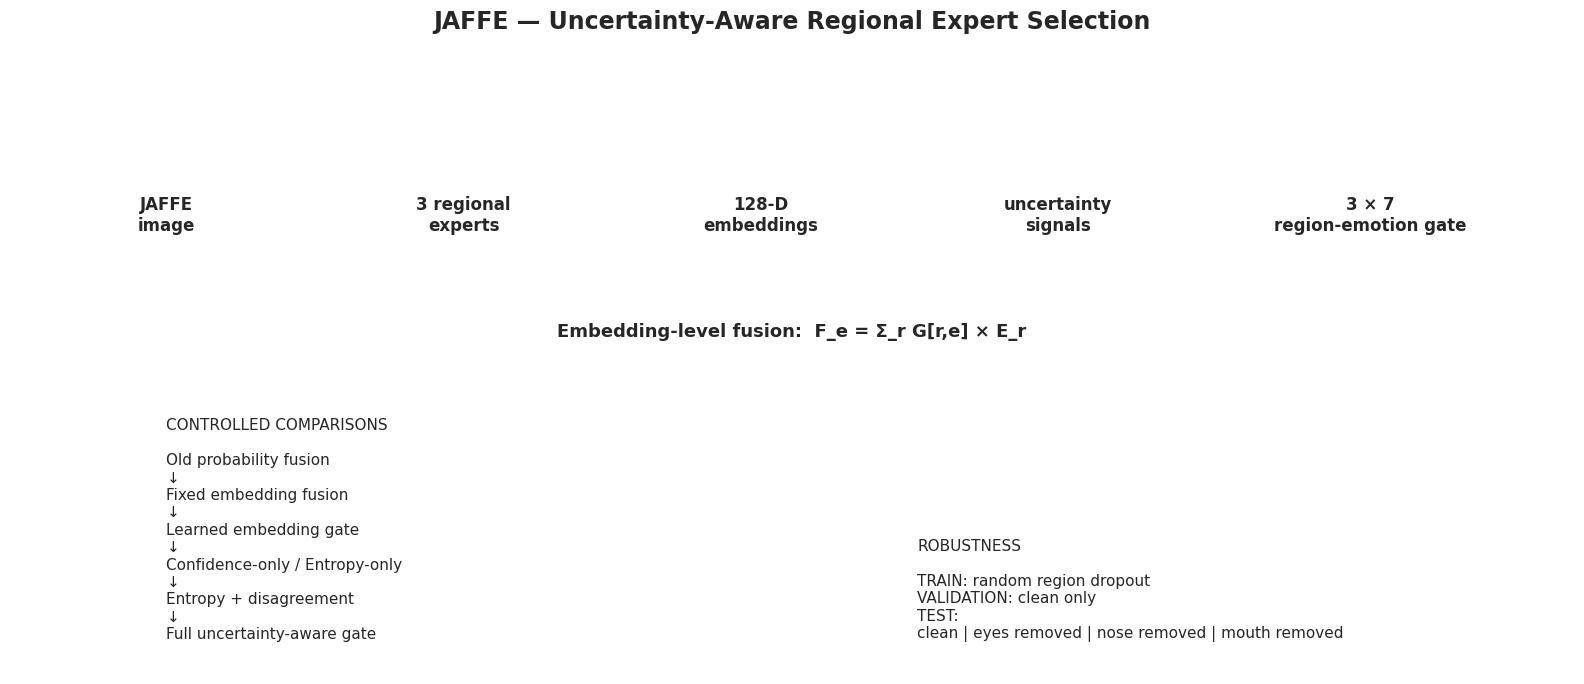

In [14]:
# 6A. ONE-PAGE EXPERIMENT MAP

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis("off")

pipeline = [
    (0.03, 0.63, 0.14, 0.18, "JAFFE\nimage"),
    (0.22, 0.63, 0.14, 0.18, "3 regional\nexperts"),
    (0.41, 0.63, 0.14, 0.18, "128-D\nembeddings"),
    (0.60, 0.63, 0.14, 0.18, "uncertainty\nsignals"),
    (0.79, 0.63, 0.16, 0.18, "3 × 7\nregion-emotion gate"),
]

for x, y, w, h, text in pipeline:
    ax.add_patch(
        plt.Rectangle(
            (x, y), w, h,
            fill=False,
            linewidth=2
        )
    )
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

for x in [0.17, 0.36, 0.55, 0.74]:
    ax.annotate(
        "",
        xy=(x + 0.05, 0.72),
        xytext=(x, 0.72),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2
        )
    )

ax.text(
    0.50, 0.53,
    "Embedding-level fusion:  F_e = Σ_r G[r,e] × E_r",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    0.10, 0.05,
    "CONTROLLED COMPARISONS\n\n"
    "Old probability fusion\n"
    "↓\n"
    "Fixed embedding fusion\n"
    "↓\n"
    "Learned embedding gate\n"
    "↓\n"
    "Confidence-only / Entropy-only\n"
    "↓\n"
    "Entropy + disagreement\n"
    "↓\n"
    "Full uncertainty-aware gate",
    fontsize=11,
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.6",
        fill=False,
        linewidth=1.5
    )
)

ax.text(
    0.58, 0.05,
    "ROBUSTNESS\n\n"
    "TRAIN: random region dropout\n"
    "VALIDATION: clean only\n"
    "TEST:\n"
    "clean | eyes removed | nose removed | mouth removed",
    fontsize=11,
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.6",
        fill=False,
        linewidth=1.5
    )
)

ax.set_title(
    "JAFFE — Uncertainty-Aware Regional Expert Selection",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    OUT_DIR / "00_experiment_map.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

## 6. Results


In [15]:
SEEDS = sorted({k[1] for k in RUNS})
CFG_ORDER = [c for c in CONFIGS if any((c, s) in RUNS for s in SEEDS)]

def ece_score(prob, y, n_bins=10):
    conf, pred = prob.max(1), prob.argmax(1)
    correct = (pred == y); bins = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return ece

rows = []
for (cfg, seed), rec in RUNS.items():
    for cond in COND_NAMES:
        p = rec['conds'][cond]['prob']; pred = p.argmax(1)
        rows.append(dict(config=cfg, seed=seed, condition=cond,
                         accuracy=accuracy_score(rec['y_true'], pred) * 100,
                         macro_f1=f1_score(rec['y_true'], pred, average='macro', zero_division=0) * 100,
                         ece=ece_score(p, rec['y_true'])))
df = pd.DataFrame(rows)
df['config'] = pd.Categorical(df['config'], CFG_ORDER, ordered=True)

def wide(metric):
    w = df.pivot_table(index=['config', 'seed'], columns='condition', values=metric)[COND_NAMES]
    occ = [c for c in COND_NAMES if c != 'Clean']
    w['Avg occluded'] = w[occ].mean(axis=1)
    w['Worst occluded'] = w[occ].min(axis=1)
    return w

def mean_std_table(metric):
    w = wide(metric)
    m, s = w.groupby(level=0, observed=True).mean(), w.groupby(level=0, observed=True).std().fillna(0)
    return m, s, m.round(2).astype(str) + ' ± ' + s.round(2).astype(str)

acc_mean, acc_std, acc_txt = mean_std_table('accuracy')
f1_mean,  f1_std,  f1_txt  = mean_std_table('macro_f1')
wide_acc = wide('accuracy')

print(f'ACCURACY (%)   mean ± std over {len(SEEDS)} split(s)')
display(acc_txt)
print('MACRO-F1 (%)')
display(f1_txt)

ece_clean = df[df.condition == 'Clean'].groupby('config', observed=True)['ece'].agg(['mean', 'std']).round(4)
print('Calibration on clean test set (ECE, lower is better)')
display(ece_clean)

acc_txt.to_csv(OUT_DIR / 'table_accuracy.csv'); f1_txt.to_csv(OUT_DIR / 'table_macro_f1.csv')
df.to_csv(OUT_DIR / 'all_results_long.csv', index=False)


ACCURACY (%)   mean ± std over 3 split(s)


condition,Clean,Eyes occluded,Nose occluded,Mouth occluded,Avg occluded,Worst occluded
config,,,,,,
Prob. fusion (old),43.72 ± 10.84,33.57 ± 5.18,42.89 ± 15.24,28.11 ± 3.86,34.86 ± 8.08,28.11 ± 3.86
Fixed,39.02 ± 5.44,36.67 ± 4.96,42.12 ± 13.9,28.15 ± 2.69,35.65 ± 5.44,28.15 ± 2.69
Learned,34.42 ± 5.37,32.78 ± 4.32,35.92 ± 5.16,27.37 ± 12.03,32.02 ± 1.81,25.03 ± 9.8
Confidence-only,39.9 ± 6.78,34.31 ± 7.13,35.11 ± 8.11,29.73 ± 9.65,33.05 ± 2.76,25.78 ± 6.99
Entropy-only,39.9 ± 7.54,35.9 ± 4.44,40.64 ± 7.24,27.35 ± 8.21,34.63 ± 0.89,26.58 ± 7.19
Entropy+Disagree,40.68 ± 6.01,35.11 ± 5.78,39.0 ± 12.57,28.18 ± 10.43,34.1 ± 2.34,25.8 ± 8.49
Full uncertainty,38.3 ± 2.99,32.76 ± 6.67,36.69 ± 8.64,27.37 ± 7.63,32.28 ± 1.99,25.01 ± 5.9
Fixed (no RD),39.0 ± 7.79,28.09 ± 5.95,43.78 ± 9.88,35.97 ± 4.07,35.95 ± 5.17,28.09 ± 5.95
Full uncertainty (no RD),40.7 ± 8.14,31.21 ± 5.57,31.32 ± 11.36,28.17 ± 5.04,30.23 ± 4.1,22.68 ± 3.83


MACRO-F1 (%)


condition,Clean,Eyes occluded,Nose occluded,Mouth occluded,Avg occluded,Worst occluded
config,,,,,,
Prob. fusion (old),35.73 ± 13.06,25.9 ± 5.82,36.72 ± 19.9,20.24 ± 1.71,27.62 ± 9.12,20.24 ± 1.71
Fixed,33.27 ± 4.76,26.53 ± 2.94,34.32 ± 12.01,20.54 ± 2.25,27.13 ± 5.66,20.54 ± 2.25
Learned,28.26 ± 7.66,22.26 ± 1.4,29.35 ± 3.94,20.51 ± 12.26,24.04 ± 2.74,16.8 ± 8.07
Confidence-only,34.76 ± 9.95,26.74 ± 5.52,27.79 ± 5.98,22.48 ± 7.96,25.67 ± 1.74,19.71 ± 5.75
Entropy-only,33.98 ± 10.74,29.89 ± 1.25,34.31 ± 7.5,18.18 ± 7.28,27.46 ± 1.7,18.18 ± 7.28
Entropy+Disagree,35.26 ± 8.73,27.1 ± 3.2,32.27 ± 11.97,20.37 ± 10.78,26.58 ± 1.38,18.66 ± 9.01
Full uncertainty,31.27 ± 5.06,26.15 ± 5.36,29.33 ± 7.44,19.69 ± 6.2,25.06 ± 1.87,18.94 ± 5.76
Fixed (no RD),31.24 ± 8.54,19.84 ± 4.39,37.27 ± 9.12,28.77 ± 3.24,28.63 ± 4.6,19.84 ± 4.39
Full uncertainty (no RD),33.05 ± 10.91,24.68 ± 2.85,22.88 ± 14.79,19.94 ± 4.6,22.5 ± 5.84,16.24 ± 7.42


Calibration on clean test set (ECE, lower is better)


,mean,std
config,,
Prob. fusion (old),0.1417,0.1106
Fixed,0.1773,0.0858
Learned,0.1905,0.0211
Confidence-only,0.1139,0.0200
Entropy-only,0.1454,0.0167
Entropy+Disagree,0.1019,0.0319
Full uncertainty,0.1348,0.0393
Fixed (no RD),0.2188,0.0033
Full uncertainty (no RD),0.1744,0.0682


In [16]:
# experiment_table = pd.DataFrame([
#     {
#         "ID": 0,
#         "Configuration": "Prob. fusion (old)",
#         "Gate input": "None",
#         "Fusion": "Probabilities",
#         "Uncertainty": "None",
#         "Random region dropout": "Yes"
#     },
#     {
#         "ID": 1,
#         "Configuration": "Fixed",
#         "Gate input": "Constant 1/3",
#         "Fusion": "Embeddings",
#         "Uncertainty": "None",
#         "Random region dropout": "Yes"
#     },
#     {
#         "ID": 2,
#         "Configuration": "Learned",
#         "Gate input": "Embeddings",
#         "Fusion": "Embeddings",
#         "Uncertainty": "None",
#         "Random region dropout": "Yes"
#     },
#     {
#         "ID": 3,
#         "Configuration": "Confidence-only",
#         "Gate input": "Confidence margin",
#         "Fusion": "Embeddings",
#         "Uncertainty": "Confidence",
#         "Random region dropout": "Yes"
#     },
#     {
#         "ID": 4,
#         "Configuration": "Entropy-only",
#         "Gate input": "Entropy",
#         "Fusion": "Embeddings",
#         "Uncertainty": "Entropy",
#         "Random region dropout": "Yes"
#     },
#     {
#         "ID": 5,
#         "Configuration": "Entropy+Disagree",
#         "Gate input": "Entropy + disagreement",
#         "Fusion": "Embeddings",
#         "Uncertainty": "2 signals",
#         "Random region dropout": "Yes"
#     },
#     {
#         "ID": 6,
#         "Configuration": "Full uncertainty",
#         "Gate input": "Embeddings + 4 uncertainty signals",
#         "Fusion": "Embeddings",
#         "Uncertainty": "Full",
#         "Random region dropout": "Yes"
#     },
# ])

# display(experiment_table)

# experiment_table.to_csv(
#     OUT_DIR / "experiment_design_table.csv",
#     index=False
# )

,ID,Configuration,Gate input,Fusion,Uncertainty,Random region dropout
0,0,Prob. fusion (old),None,Probabilities,None,Yes
1,1,Fixed,Constant 1/3,Embeddings,None,Yes
2,2,Learned,Embeddings,Embeddings,None,Yes
3,3,Confidence-only,Confidence margin,Embeddings,Confidence,Yes
4,4,Entropy-only,Entropy,Embeddings,Entropy,Yes
5,5,Entropy+Disagree,Entropy + disagreement,Embeddings,2 signals,Yes
6,6,Full uncertainty,Embeddings + 4 uncertainty signals,Embeddings,Full,Yes


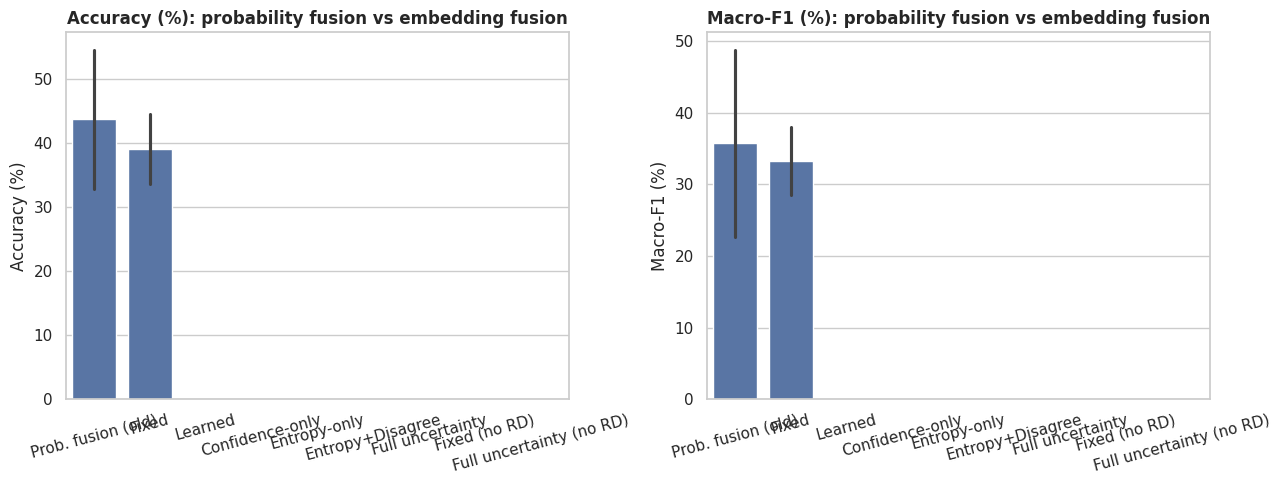

In [17]:
# =============================================================================
# 6B. PROBABILITY FUSION VS EMBEDDING FUSION
# =============================================================================

comparison_configs = [
    c for c in [
        "Prob. fusion (old)",
        "Fixed"
    ]
    if c in CFG_ORDER
]

if len(comparison_configs) == 2:

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13, 5)
    )

    for ax, metric, title in zip(
        axes,
        ["accuracy", "macro_f1"],
        ["Accuracy (%)", "Macro-F1 (%)"]
    ):

        tmp = df[
            (df["config"].isin(comparison_configs))
            & (df["condition"] == "Clean")
        ].copy()

        sns.barplot(
            data=tmp,
            x="config",
            y=metric,
            errorbar="sd",
            ax=ax
        )

        ax.set_title(
            f"{title}: probability fusion vs embedding fusion",
            fontweight="bold"
        )
        ax.set_xlabel("")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", rotation=15)

    plt.tight_layout()

    plt.savefig(
        OUT_DIR / "04a_probability_vs_embedding_fusion.png",
        dpi=160,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("Run both 'Prob. fusion (old)' and 'Fixed' to create this comparison.")

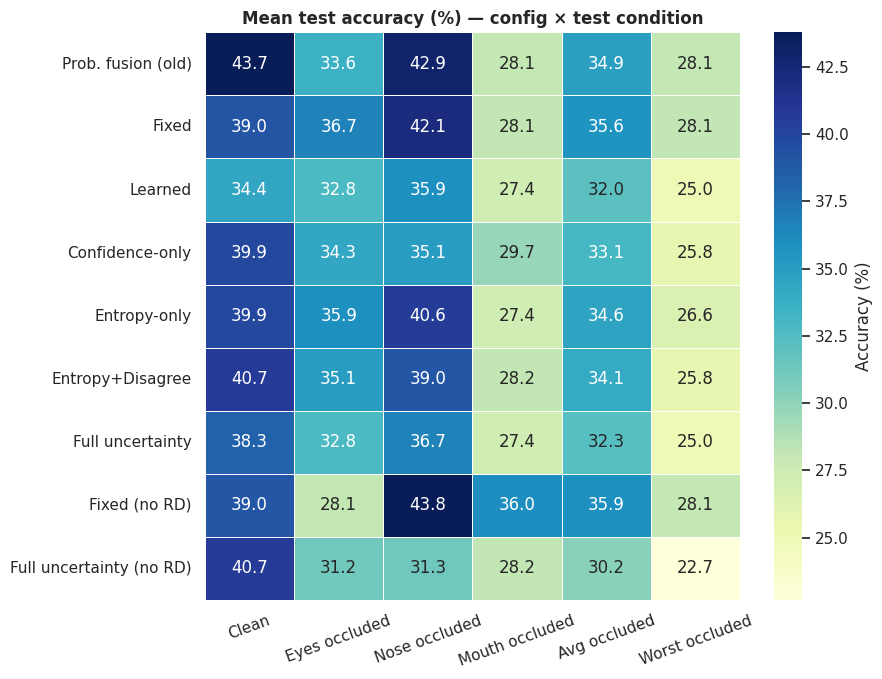

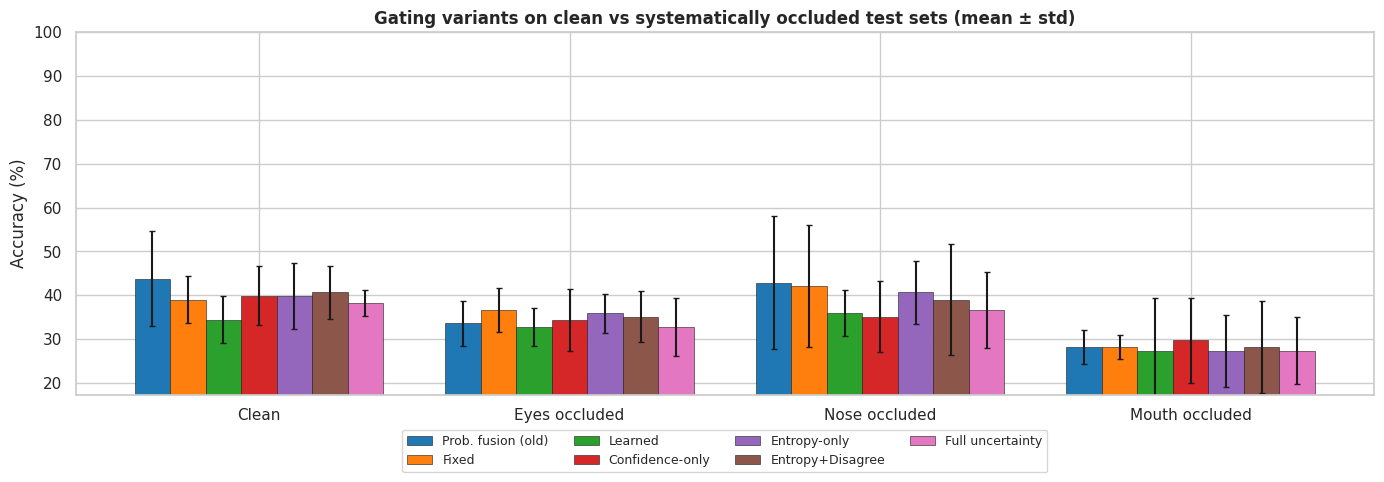

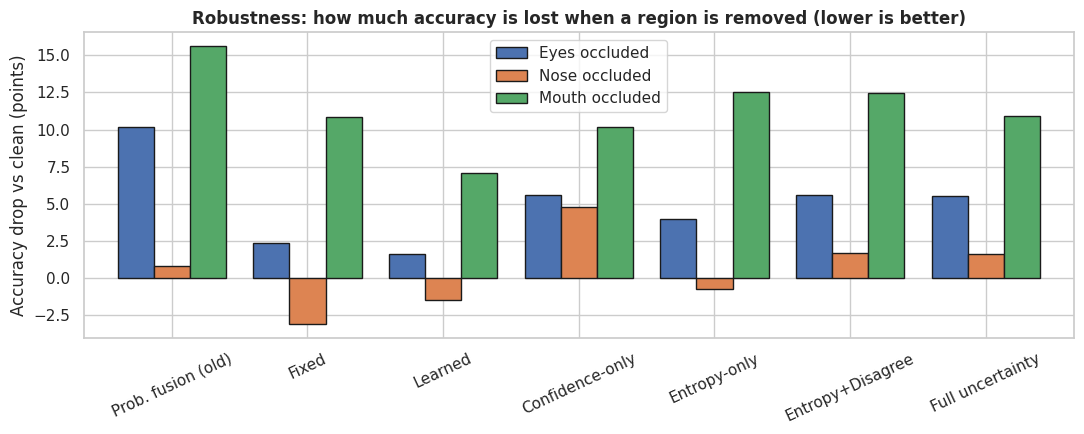

In [18]:
# ---- (a) heatmap of mean accuracy ----
fig, ax = plt.subplots(figsize=(9, 0.55 * len(CFG_ORDER) + 2))
sns.heatmap(acc_mean, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Accuracy (%)'}, ax=ax, linewidths=.5)
ax.set_title('Mean test accuracy (%) — config × test condition', fontweight='bold'); ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig(OUT_DIR / '04_heatmap_accuracy.png', dpi=150, bbox_inches='tight'); plt.show()

# ---- (b) grouped bars: 6 gating variants (+ old prob. fusion) on the 4 test conditions ----
main = [c for c in MAIN_CONFIGS if c in CFG_ORDER]
fig, ax = plt.subplots(figsize=(14, 5))
w = 0.8 / len(main); xs = np.arange(len(COND_NAMES)); pal = sns.color_palette('tab10', len(main))
for j, cfg in enumerate(main):
    ax.bar(xs + (j - (len(main) - 1) / 2) * w, acc_mean.loc[cfg, COND_NAMES], w, yerr=acc_std.loc[cfg, COND_NAMES],
           capsize=2, label=cfg, color=pal[j], edgecolor='k', linewidth=.4)
ax.set_xticks(xs); ax.set_xticklabels(COND_NAMES); ax.set_ylabel('Accuracy (%)')
lo = max(0, acc_mean.loc[main, COND_NAMES].values.min() - 10)
ax.set_ylim(lo, 100); ax.legend(ncol=4, fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.08))
ax.set_title('Gating variants on clean vs systematically occluded test sets (mean ± std)', fontweight='bold')
plt.tight_layout(); plt.savefig(OUT_DIR / '05_grouped_bars.png', dpi=150, bbox_inches='tight'); plt.show()

# ---- (c) robustness: accuracy DROP relative to clean ----
occ_conds = [c for c in COND_NAMES if c != 'Clean']
drop = pd.DataFrame({c: acc_mean['Clean'] - acc_mean[c] for c in occ_conds})
fig, ax = plt.subplots(figsize=(11, 4.5))
drop.loc[main].plot(kind='bar', ax=ax, edgecolor='k', width=.8)
ax.set_ylabel('Accuracy drop vs clean (points)'); ax.set_xlabel('')
ax.set_title('Robustness: how much accuracy is lost when a region is removed (lower is better)', fontweight='bold')
ax.tick_params(axis='x', rotation=25); ax.legend(title='')
plt.tight_layout(); plt.savefig(OUT_DIR / '06_robustness_drop.png', dpi=150, bbox_inches='tight'); plt.show()


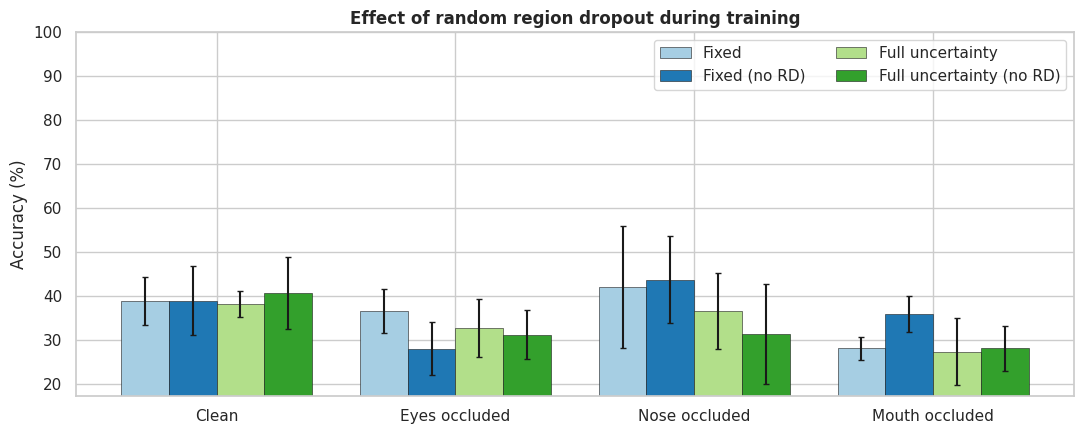

In [19]:
# ---- region-dropout ablation: same model with / without random region dropout in training ----
pairs = [c for c in ['Fixed', 'Fixed (no RD)', 'Full uncertainty', 'Full uncertainty (no RD)'] if c in CFG_ORDER]
if len(pairs) >= 2:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    w = 0.8 / len(pairs); xs = np.arange(len(COND_NAMES)); pal = sns.color_palette('Paired', len(pairs))
    for j, cfg in enumerate(pairs):
        ax.bar(xs + (j - (len(pairs) - 1) / 2) * w, acc_mean.loc[cfg, COND_NAMES], w,
               yerr=acc_std.loc[cfg, COND_NAMES], capsize=2, label=cfg, color=pal[j], edgecolor='k', linewidth=.4)
    ax.set_xticks(xs); ax.set_xticklabels(COND_NAMES); ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(max(0, acc_mean.loc[pairs, COND_NAMES].values.min() - 10), 100); ax.legend(ncol=2)
    ax.set_title('Effect of random region dropout during training', fontweight='bold')
    plt.tight_layout(); plt.savefig(OUT_DIR / '07_region_dropout_ablation.png', dpi=150, bbox_inches='tight'); plt.show()
else:
    print('No-RD configs were not run (QUICK_TEST).')


In [1]:
# # ---- paired comparison against FIXED fusion (same splits) ----
# base = 'Fixed'
# rows = []
# for cfg in CFG_ORDER:
#     if cfg == base: continue
#     d_clean = (wide_acc.loc[cfg]['Clean'].values - wide_acc.loc[base]['Clean'].values)
#     d_occ   = (wide_acc.loc[cfg]['Avg occluded'].values - wide_acc.loc[base]['Avg occluded'].values)
#     d_worst = (wide_acc.loc[cfg]['Worst occluded'].values - wide_acc.loc[base]['Worst occluded'].values)
#     rows.append({'config': cfg,
#                  'Δ Clean': d_clean.mean(), 'Δ Avg occluded': d_occ.mean(), 'Δ Worst occluded': d_worst.mean(),
#                  'splits better (clean)': f'{(d_clean > 0).sum()}/{len(d_clean)}',
#                  'splits better (occluded)': f'{(d_occ > 0).sum()}/{len(d_occ)}'})
# paired = pd.DataFrame(rows).set_index('config').round(2)
# print(f'Difference in accuracy (points) vs "{base}" — positive = better than fixed fusion')
# display(paired.style.background_gradient(cmap='RdYlGn', subset=['Δ Clean', 'Δ Avg occluded', 'Δ Worst occluded'], vmin=-5, vmax=5))
# paired.to_csv(OUT_DIR / 'table_paired_vs_fixed.csv')
# print('NOTE: with small test sets, differences of 1-2 points are within noise — look at std and "splits better".')


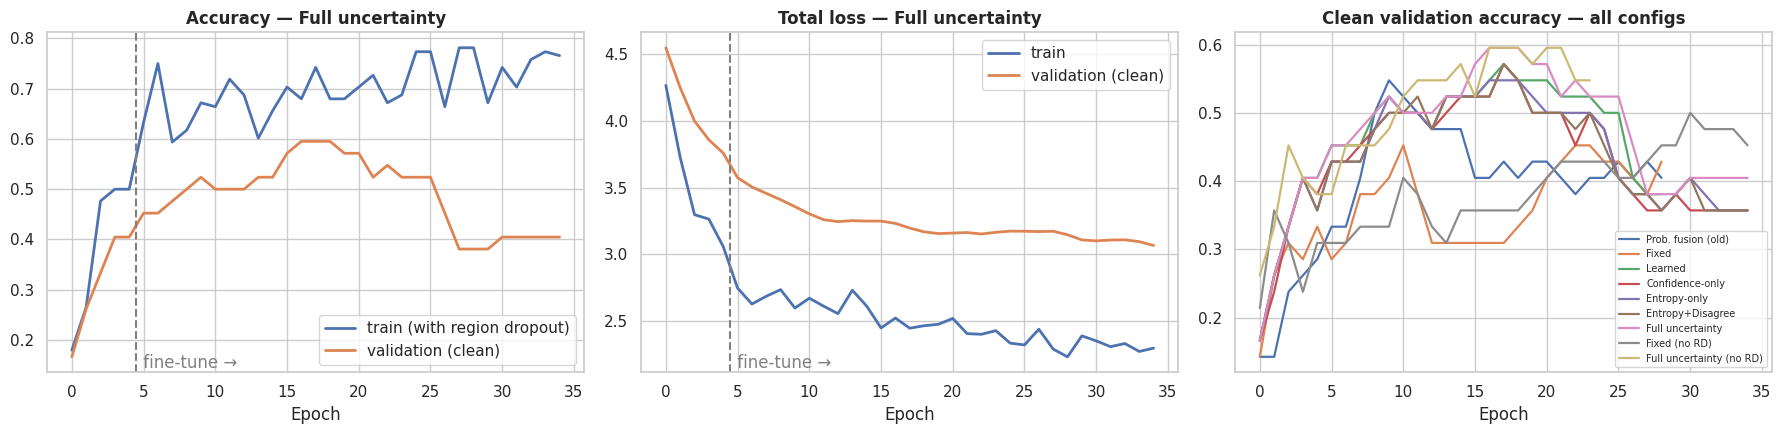

In [21]:
# ---- training curves (first split) ----
seed0 = SEEDS[0]
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
rec = RUNS[(FULL, seed0)]; h = rec['hist']; wl = rec['warmup_len']
acc_k = [k for k in h if 'final_out' in k and 'accuracy' in k and not k.startswith('val_')][0]
ax[0].plot(h[acc_k], label='train (with region dropout)', lw=2); ax[0].plot(h['val_' + acc_k], label='validation (clean)', lw=2)
ax[1].plot(h['loss'], label='train', lw=2); ax[1].plot(h['val_loss'], label='validation (clean)', lw=2)
for a, t in zip(ax[:2], ['Accuracy — ' + FULL, 'Total loss — ' + FULL]):
    a.axvline(wl - 0.5, color='gray', ls='--'); a.text(wl - 0.4, a.get_ylim()[0], ' fine-tune →', va='bottom', color='gray')
    a.set_title(t, fontweight='bold'); a.set_xlabel('Epoch'); a.legend()
for cfg in CFG_ORDER:
    if (cfg, seed0) in RUNS:
        hh = RUNS[(cfg, seed0)]['hist']
        k = [k for k in hh if 'final_out' in k and 'accuracy' in k and k.startswith('val_')][0]
        ax[2].plot(hh[k], label=cfg, lw=1.6)
ax[2].set_title('Clean validation accuracy — all configs', fontweight='bold'); ax[2].set_xlabel('Epoch'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUT_DIR / '08_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()


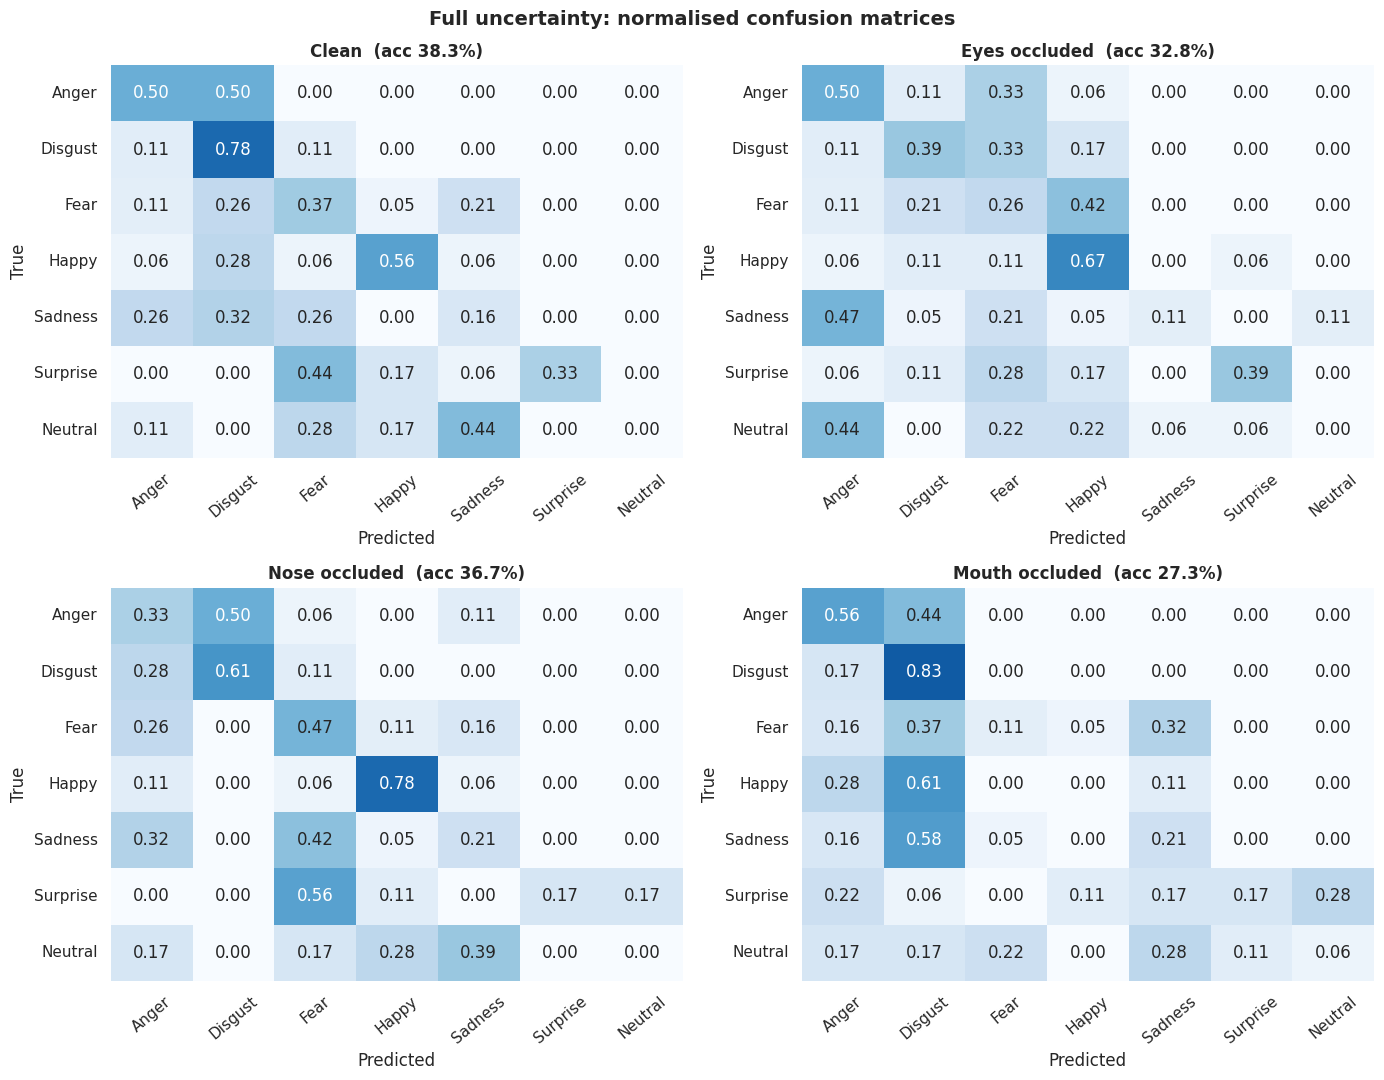

Classification report — Full uncertainty, clean test sets pooled over splits
              precision    recall  f1-score   support

       Anger      0.429     0.500     0.462        18
     Disgust      0.359     0.778     0.491        18
        Fear      0.250     0.368     0.298        19
       Happy      0.588     0.556     0.571        18
     Sadness      0.176     0.158     0.167        19
    Surprise      1.000     0.333     0.500        18
     Neutral      0.000     0.000     0.000        18

    accuracy                          0.383       128
   macro avg      0.400     0.385     0.356       128
weighted avg      0.397     0.383     0.354       128



In [22]:
# ---- confusion matrices of the full model on the 4 test conditions (pooled over splits) ----
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, cond in zip(axes.ravel(), COND_NAMES):
    yt = np.concatenate([RUNS[(FULL, s)]['y_true'] for s in SEEDS if (FULL, s) in RUNS])
    yp = np.concatenate([RUNS[(FULL, s)]['conds'][cond]['prob'].argmax(1) for s in SEEDS if (FULL, s) in RUNS])
    cm = confusion_matrix(yt, yp, labels=np.arange(NUM_CLASSES)); cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(f'{cond}  (acc {accuracy_score(yt, yp)*100:.1f}%)', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.tick_params(axis='x', rotation=40)
plt.suptitle(f'{FULL}: normalised confusion matrices', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(OUT_DIR / '09_confusion_matrices.png', dpi=150, bbox_inches='tight'); plt.show()

yt = np.concatenate([RUNS[(FULL, s)]['y_true'] for s in SEEDS if (FULL, s) in RUNS])
yp = np.concatenate([RUNS[(FULL, s)]['conds']['Clean']['prob'].argmax(1) for s in SEEDS if (FULL, s) in RUNS])
print(f'Classification report — {FULL}, clean test sets pooled over splits')
print(classification_report(yt, yp, target_names=CLASS_NAMES, digits=3, zero_division=0))


In [3]:
# GATED = [c for c in ['Learned', 'Confidence-only', 'Entropy-only', 'Entropy+Disagree', 'Full uncertainty'] if c in CFG_ORDER]
# occ_region = {'Eyes occluded': 0, 'Nose occluded': 1, 'Mouth occluded': 2}

# def region_weight(cfg, cond):
#     # mean gate weight per region (averaged over test images and emotions) -> (n_splits, 3)
#     return np.array([RUNS[(cfg, s)]['conds'][cond]['gate'].mean(axis=(0, 2)) for s in SEEDS if (cfg, s) in RUNS])

# # ---- (a) weight given to the OCCLUDED region, per gate type ----
# fig, ax = plt.subplots(figsize=(11, 4.5))
# w = 0.8 / 3; xs = np.arange(len(GATED)); pal = sns.color_palette('Set2', 3)
# for j, (cond, r) in enumerate(occ_region.items()):
#     vals = [region_weight(c, cond)[:, r] for c in GATED]
#     ax.bar(xs + (j - 1) * w, [v.mean() for v in vals], w, yerr=[v.std() for v in vals], capsize=3,
#            label=cond.replace(' occluded', '') + ' removed', color=pal[j], edgecolor='k')
# ax.axhline(1 / 3, color='red', ls='--', label='uniform weight (1/3)')
# ax.set_xticks(xs); ax.set_xticklabels(GATED, rotation=15); ax.set_ylabel('Gate weight of the removed region')
# ax.set_title('Does the gate down-weight the missing region? (lower = better)', fontweight='bold'); ax.legend(ncol=2, fontsize=9)
# plt.tight_layout(); plt.savefig(OUT_DIR / '10_gate_weight_of_removed_region.png', dpi=150, bbox_inches='tight'); plt.show()

# # ---- (b) region weights per condition for the FULL gate ----
# fig, ax = plt.subplots(figsize=(9, 4.5)); w = 0.8 / 3; xs = np.arange(len(COND_NAMES)); pal = sns.color_palette('Set1', 3)
# for j, name in enumerate(REGIONS):
#     vals = [region_weight(FULL, c)[:, j] for c in COND_NAMES]
#     ax.bar(xs + (j - 1) * w, [v.mean() for v in vals], w, yerr=[v.std() for v in vals], capsize=3, label=name,
#            color=pal[j], edgecolor='k')
# ax.axhline(1 / 3, color='k', ls='--', lw=1)
# ax.set_xticks(xs); ax.set_xticklabels(COND_NAMES); ax.set_ylabel('Mean gate weight'); ax.legend(title='expert')
# ax.set_title(f'{FULL}: average weight given to each regional expert', fontweight='bold')
# plt.tight_layout(); plt.savefig(OUT_DIR / '11_full_gate_region_weights.png', dpi=150, bbox_inches='tight'); plt.show()

# # ---- (c) the learned (regions x emotions) matrix, averaged over all test images and splits ----
# fig, axes = plt.subplots(1, 4, figsize=(20, 3.6), sharey=True)
# for ax, cond in zip(axes, COND_NAMES):
#     M = np.mean([RUNS[(FULL, s)]['conds'][cond]['gate'].mean(0) for s in SEEDS if (FULL, s) in RUNS], axis=0)
#     sns.heatmap(M, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=0.8, xticklabels=CLASS_NAMES,
#                 yticklabels=REGIONS, ax=ax, cbar=ax is axes[-1])
#     ax.set_title(cond, fontweight='bold'); ax.tick_params(axis='x', rotation=45)
# plt.suptitle(f'{FULL}: average (regions × emotions) gate matrix', fontweight='bold', y=1.04)
# plt.tight_layout(); plt.savefig(OUT_DIR / '12_gate_matrix_regions_x_emotions.png', dpi=150, bbox_inches='tight'); plt.show()


In [2]:
# # ---- expert-level uncertainty and accuracy (FULL model) ----
# def ent(p):
#     return -(p * np.log(p + 1e-8)).sum(-1) / np.log(p.shape[-1])

# ent_tab = np.zeros((N_REG, len(COND_NAMES))); acc_tab = np.zeros((N_REG, len(COND_NAMES)))
# for j, cond in enumerate(COND_NAMES):
#     e_list, a_list = [], []
#     for s in SEEDS:
#         rec = RUNS[(FULL, s)]; rp = rec['conds'][cond]['region_prob']
#         e_list.append(ent(rp).mean(0))
#         a_list.append([(rp[:, k].argmax(1) == rec['y_true']).mean() * 100 for k in range(N_REG)])
#     ent_tab[:, j] = np.mean(e_list, 0); acc_tab[:, j] = np.mean(a_list, 0)

# fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
# sns.heatmap(pd.DataFrame(ent_tab, index=REGIONS, columns=COND_NAMES), annot=True, fmt='.2f', cmap='Reds', ax=ax[0], vmin=0, vmax=1)
# ax[0].set_title('Mean normalised entropy of each expert\n(higher = more uncertain)', fontweight='bold')
# sns.heatmap(pd.DataFrame(acc_tab, index=REGIONS, columns=COND_NAMES), annot=True, fmt='.1f', cmap='Greens', ax=ax[1], vmin=0, vmax=100)
# ax[1].set_title('Accuracy of each expert on its own (%)', fontweight='bold')
# plt.tight_layout(); plt.savefig(OUT_DIR / '13_expert_uncertainty.png', dpi=150, bbox_inches='tight'); plt.show()

# # ---- confidence of the final prediction: correct vs wrong (clean test) ----
# conf_c, conf_w = [], []
# for s in SEEDS:
#     rec = RUNS[(FULL, s)]; p = rec['conds']['Clean']['prob']; ok = p.argmax(1) == rec['y_true']
#     conf_c += list(p.max(1)[ok]); conf_w += list(p.max(1)[~ok])
# fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# ax[0].hist(conf_c, bins=15, alpha=.7, color='green', label=f'correct (mean {np.mean(conf_c):.2f})')
# if len(conf_w): ax[0].hist(conf_w, bins=15, alpha=.7, color='red', label=f'wrong (mean {np.mean(conf_w):.2f})')
# ax[0].set_xlabel('Max softmax confidence'); ax[0].set_ylabel('Images'); ax[0].legend()
# ax[0].set_title(f'{FULL}: confidence, clean test', fontweight='bold')

# # reliability diagram
# P = np.concatenate([RUNS[(FULL, s)]['conds']['Clean']['prob'] for s in SEEDS]); Y = np.concatenate([RUNS[(FULL, s)]['y_true'] for s in SEEDS])
# conf, corr = P.max(1), P.argmax(1) == Y; bins = np.linspace(0, 1, 11); bx, by = [], []
# for lo, hi in zip(bins[:-1], bins[1:]):
#     m = (conf > lo) & (conf <= hi)
#     if m.sum() >= 3: bx.append(conf[m].mean()); by.append(corr[m].mean())
# ax[1].plot([0, 1], [0, 1], 'k--', label='perfect calibration'); ax[1].plot(bx, by, 'o-', label=f'model (ECE {ece_score(P, Y):.3f})')
# ax[1].set_xlabel('Confidence'); ax[1].set_ylabel('Accuracy'); ax[1].legend(); ax[1].set_title('Reliability diagram (clean test)', fontweight='bold')
# plt.tight_layout(); plt.savefig(OUT_DIR / '14_confidence_calibration.png', dpi=150, bbox_inches='tight'); plt.show()


In [4]:
# # ---- one test image: crops, gate weights and prediction under each condition ----
# rec = RUNS[(FULL, SEEDS[0])]; te_idx = rec['test_idx']
# ok = rec['conds']['Clean']['prob'].argmax(1) == rec['y_true']
# n = int(np.where(ok)[0][0]) if ok.any() else 0
# i_img = te_idx[n]; base = make_inputs(np.array([i_img]))
# fig, axes = plt.subplots(4, 4, figsize=(13, 11))
# for r, cond in enumerate(COND_NAMES):
#     sample = base if cond == 'Clean' else occlude(base, REGIONS[occ_region[cond]])
#     for k, name in enumerate(REGIONS):
#         axes[r, k].imshow(sample[f'{name}_in'][0].astype('uint8')); axes[r, k].axis('off')
#         if r == 0: axes[r, k].set_title(name, fontsize=12)
#     g = rec['conds'][cond]['gate'][n].mean(1); p = rec['conds'][cond]['prob'][n]
#     axes[r, 3].bar(REGIONS, g, color=[REG_COLORS[x] for x in REGIONS], edgecolor='k'); axes[r, 3].axhline(1 / 3, color='k', ls='--', lw=1)
#     axes[r, 3].set_ylim(0, 1); axes[r, 3].set_ylabel('gate weight')
#     axes[r, 3].set_title(f'{cond}\npred: {CLASS_NAMES[p.argmax()]} ({p.max():.2f})', fontsize=10,
#                          color='green' if p.argmax() == labels[i_img] else 'red')
# plt.suptitle(f'{FULL} — true emotion: {CLASS_NAMES[labels[i_img]]}', fontsize=14, fontweight='bold')
# plt.tight_layout(); plt.savefig(OUT_DIR / '15_sample_gate_weights.png', dpi=150, bbox_inches='tight'); plt.show()
